# Sequential Bootstrap Diagnostics

Indicator matrix, average uniqueness and sequential-bootstrap draw probabilities (AFML Ch. 4) on a
hand-written set of five overlapping labels.

`seq_bootstrap` is seeded with `random_state=42`, so the drawn indices below are reproducible; the
indicator matrix, average uniqueness and the draw probabilities of `bootstrap_loop_run` do not depend
on a seed.

In [1]:
import nbfigures
import openquant

label_endtime = [(0, 4), (2, 6), (5, 10), (9, 12), (11, 15)]
bar_index = list(range(18))
ind_mat = openquant.sampling.get_ind_matrix(label_endtime, bar_index)
uniq = openquant.sampling.get_ind_mat_average_uniqueness(ind_mat)
samples = openquant.sampling.seq_bootstrap(
    ind_mat, sample_length=8, warmup_samples=[0, 1], random_state=42
)
assert 0.0 <= uniq <= 1.0
assert len(samples) == 8
assert samples == openquant.sampling.seq_bootstrap(
    ind_mat, sample_length=8, warmup_samples=[0, 1], random_state=42
)
print(f"average uniqueness: {uniq:.4f}")
print(f"drawn labels (warm-up 0, 1; random_state=42): {samples}")

average uniqueness: 0.6333
drawn labels (warm-up 0, 1; random_state=42): [1, 0, 3, 3, 3, 2, 0, 2]


In [2]:
matrix_df = openquant.adapters.to_polars_indicator_matrix(ind_mat, bar_index=bar_index)
matrix_df.head()

bar_index,label_0,label_1,label_2,label_3,label_4
i64,i64,i64,i64,i64,i64
0,1,0,0,0,0
1,1,0,0,0,0
2,1,1,0,0,0
3,1,1,0,0,0
4,1,1,0,0,0


## Draw probabilities

`bootstrap_loop_run` returns each label's average uniqueness given the labels drawn so far; the sequential
bootstrap draws the next label with probability proportional to it. Below: the probabilities for the first
draw (nothing drawn yet, so uniform) and after labels 0 and 1 have been drawn. Labels that overlap the ones
already drawn become less likely.

first draw:         [0.2, 0.2, 0.2, 0.2, 0.2]
after drawing 0, 1: [0.1101, 0.1101, 0.2294, 0.2752, 0.2752]


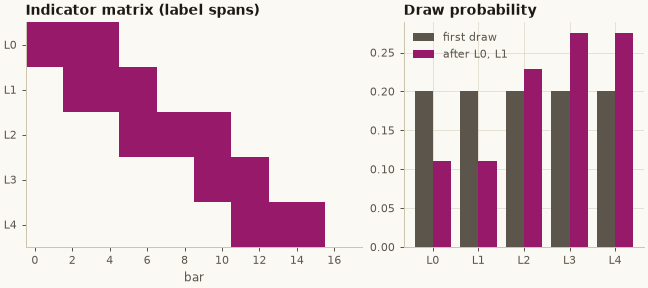

In [3]:
n_bars = len(ind_mat)
n_labels = len(ind_mat[0])


def draw_probabilities(prev_concurrency: list[float]) -> list[float]:
    avg_unique = openquant.sampling.bootstrap_loop_run(ind_mat, prev_concurrency)
    total = sum(avg_unique)
    return [u / total for u in avg_unique]


first = draw_probabilities([0.0] * n_bars)
second = draw_probabilities([float(ind_mat[t][0] + ind_mat[t][1]) for t in range(n_bars)])
labels = [f"L{j}" for j in range(n_labels)]
print("first draw:        ", [round(p, 4) for p in first])
print("after drawing 0, 1:", [round(p, 4) for p in second])


def draw(fig, c):
    left, right = fig.subplots(1, 2, width_ratios=[1.4, 1])
    left.imshow(
        [[ind_mat[t][j] for t in range(n_bars)] for j in range(n_labels)],
        aspect="auto",
        cmap=nbfigures.two_tone(c),
        interpolation="nearest",
    )
    left.set_yticks(range(n_labels), labels)
    left.set_xlabel("bar")
    left.set_title("Indicator matrix (label spans)")
    left.grid(False)
    x = range(n_labels)
    right.bar([i - 0.2 for i in x], first, width=0.4, color=c["muted"], label="first draw")
    right.bar([i + 0.2 for i in x], second, width=0.4, color=c["accent"], label="after L0, L1")
    right.set_xticks(list(x), labels)
    right.set_title("Draw probability")
    right.legend(loc="upper left")


nbfigures.figure(
    "nb02-seq-bootstrap",
    draw,
    alt="Indicator matrix of five overlapping labels and their sequential-bootstrap draw probabilities.",
)